In [96]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.special import erfc
from sklearn.metrics import confusion_matrix
import pandas as pd
import sounddevice as sd
from scipy.io.wavfile import read
from collections import Counter
from sklearn.preprocessing import StandardScaler


# OPPGAVE 1

### Kode som leser txt filen med informasjon

In [97]:
import pandas as pd

def load_genre_data_by_range(start_row, end_row, GenreClassData):
    # Les kun de nødvendige kolonnene (brukercols for å spesifisere kolonneindekser)
    cols_to_load = [2.1, 7-1, 11-1, 41-1, 42-1]  
    col_names = ["name",'spectral centroid mean', 'spectral rolloff mean', 'tempo', 'mfcc 1 mean']  
    
    data = pd.read_csv(GenreClassData, sep=r'\s+', header=None, usecols=cols_to_load)
    data.columns = col_names 
    
    row_indices = range(start_row+1, end_row + 2)
    selected_rows = data.iloc[row_indices]
    
    return selected_rows



def load_genre_data_by_type(GenreClassData):
    cols_to_load = [2-1, 7-1, 11-1, 41-1, 42-1, 68-1]  
    col_names = ["name", 'spectral centroid mean', 'spectral rolloff mean', 'tempo', 'mfcc 1 mean', "type"] 
    
    # Les data med spesifikke datatyper og hopp over header-raden
    dtype_mapping = {7-1: float, 11-1: float, 41-1: float, 42-1: float}
    data = pd.read_csv(
        GenreClassData, 
        sep=r'\s+', 
        usecols=cols_to_load, 
        dtype=dtype_mapping,
        header=0
    )
    
    # Sett kolonnenavn
    data.columns = col_names 
    
    # Filtrer trenings- og testdata
    train_data = data[data['type'] == 'Train']
    test_data = data[data['type'] == 'Test']

    # Fjern "type"-kolonnen fra trenings- og testdata
    train_data = train_data.drop(columns=['type'])
    test_data = test_data.drop(columns=['type'])
    
    return train_data, test_data


def load_genre_data_by_name(data_set, name):
    navngittdata = []  # Bruker en vanlig liste

    for rad in data_set:
        if name in rad[0]:
            navngittdata.append(list(rad[1:]))

    return navngittdata


# ================== BESTEMME FIL ====================



GenreClassData = "Music files/GenreClassData_10s.txt"


# ================== BESTEMME FIL ====================
popdata_index = [0,99]
#pop_Data = load_genre_data_by_range(popdata_index[0], popdata_index[1], GenreClassData)
#print(pop_Data)

train_data, test_data = load_genre_data_by_type(GenreClassData)
print(train_data)

pop_Data = load_genre_data_by_name(train_data.values,"pop")
#print(pop_Data)
pop_Data = np.array(pop_Data)
#print(pop_Data.shape)

                name  spectral centroid mean  spectral rolloff mean  \
0      pop_00072.wav             2862.407158            6081.955799   
1      pop_00072.wav             2545.515202            5242.860331   
2      pop_00072.wav             2299.546407            4730.010377   
3      pop_00066.wav             2893.486384            6924.948226   
4      pop_00066.wav             2672.155596            6534.527772   
...              ...                     ...                    ...   
2371  jazz_00099.wav             1610.557025            3741.706299   
2372  jazz_00099.wav             1301.565622            2940.406350   
2373  jazz_00066.wav             1619.999594            3067.132498   
2374  jazz_00066.wav             1559.231275            2918.923108   
2375  jazz_00066.wav             1557.431607            2912.028486   

           tempo  mfcc 1 mean  
0     117.453835    10.171241  
1     117.453835    -9.099434  
2     117.453835    27.695023  
3     107.666016   

#### Euclidisk avstand

In [98]:

def euclidean_distance_4d(vec1, vec2):
    """
    Beregner euklidisk avstand mellom to 4-dimensjonale vektorer.
    
    Parametere:
    vec1 : array-like
        Første 4-dimensjonale vektor.
    vec2 : array-like
        Andre 4-dimensjonale vektor.
    
    Returnerer:
    float
        Den euklidiske avstanden mellom de to vektorene.
    """
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)
    distance = np.sqrt(np.sum((vec1 - vec2) ** 2))
    return distance


## k_NN funksjon

##### Normalisert data

In [99]:
train_data, test_data = load_genre_data_by_type(GenreClassData)

scaler = StandardScaler()

train_features = train_data.iloc[:, 1:].values
test_features = test_data.iloc[:, 1:].values

train_names = train_data.iloc[:, 0].values
test_names = test_data.iloc[:, 0].values

train_scaled = scaler.fit_transform(train_features)
test_scaled = scaler.transform(test_features)

# Kombiner navnene med de skalerte funksjonene i en DataFrame
train_scaled_with_name = pd.DataFrame(
    data=train_scaled, 
    columns=train_data.columns[1:]
)
train_scaled_with_name.insert(0, "Name", train_names)

test_scaled_with_name = pd.DataFrame(
    data=test_scaled, 
    columns=test_data.columns[1:]
)
test_scaled_with_name.insert(0, "Name", test_names)

print(f"Treningsdata med navn:\n{train_scaled_with_name}\n")
print(f"Testdata med navn:\n{test_scaled_with_name}\n")

Treningsdata med navn:
                Name  spectral centroid mean  spectral rolloff mean     tempo  \
0      pop_00072.wav                0.933957               0.965045 -0.187099   
1      pop_00072.wav                0.495137               0.438493 -0.187099   
2      pop_00072.wav                0.154530               0.116668 -0.187099   
3      pop_00066.wav                0.976994               1.494042 -0.652672   
4      pop_00066.wav                0.670504               1.249044  1.907982   
...              ...                     ...                    ...       ...   
2371  jazz_00099.wav               -0.799555              -0.503516  0.695041   
2372  jazz_00099.wav               -1.227434              -1.006350  0.695041   
2373  jazz_00066.wav               -0.786480              -0.926827  0.371589   
2374  jazz_00066.wav               -0.870629              -1.019831  0.078943   
2375  jazz_00066.wav               -0.873121              -1.024158  0.371589   

    

In [100]:
def k_nn(train_data, test_instance, k):
    avstand = []
    for data in train_data:
        dist = euclidean_distance_4d(data[1:], test_instance)
        
        avstand.append((data, dist))
    avstand.sort(key=lambda x: x[1])
    k_nearest = avstand[:k]
    
    classes = [neighbor[0][0].split('_')[0] for neighbor in k_nearest]
    class_counts = Counter(classes)
    #MÅ LEGGE TIL NOE SOM BEHANDLER OM DET ER LIK MANGE AV TO KLASSER, DA VIL DEN VELGE DEN SOM ER NÆRMEST
    
    # Finn klassen(e) med høyest antall
    max_count = max(class_counts.values())
    tied_classes = [cls for cls, count in class_counts.items() if count == max_count]
    
    if len(tied_classes) > 1:  # Hvis det er en tie
        for neighbor in k_nearest:
            neighbor_class = neighbor[0][0].split('_')[0]
            if neighbor_class in tied_classes:
                most_common_class = neighbor_class
                break
    else:
        most_common_class = tied_classes[0]
    
    #print(f"Klassefordeling: {class_counts}")
    #print(f"Mest vanlig klasse: {most_common_class}, Antall: {count}")
    
    data_points = [neighbor[0] for neighbor in k_nearest]
    distances = [neighbor[1] for neighbor in k_nearest]
    data_points_array = np.array(data_points)
    distances_array = np.array(distances)

    return most_common_class, data_points_array, distances_array


#Eksempelbruk
test_data_tilfellet = test_data.values[4][1:]
print(f"Testdata tilfelle: {test_data_tilfellet}")
k_nearest = k_nn(train_data.values, test_data_tilfellet, 5)

print(f"Predikert klasse: {k_nearest[0]}")
print(f"Nærmeste naboer:\n{k_nearest[1]}")
print(f"Avstander til nærmeste naboer:\n{k_nearest[2]}")



Testdata tilfelle: [2846.0667822342275 5530.36106755728 99.38401442307692 -78.00435638427734]
Predikert klasse: disco
Nærmeste naboer:
[['disco_00008.wav' 2846.5554651934262 5516.297038138051 123.046875
  -32.28793716430664]
 ['metal_00036.wav' 2801.6904775667413 5529.536710593097
  135.99917763157896 -76.82715606689453]
 ['rock_00041.wav' 2810.6432960877037 5566.407949354699
  117.45383522727272 -36.98381805419922]
 ['hiphop_00001.wav' 2849.6510907009033 5598.482929415603 92.28515625
  -86.59770202636719]
 ['disco_00072.wav' 2849.1131317301843 5587.891191451567
  135.99917763157896 -89.60199737548828]]
Avstander til nærmeste naboer:
[53.36625986 57.54990841 67.55297215 69.1207256  69.23995128]


## Evaluering

In [108]:
train_data, test_data = load_genre_data_by_type(GenreClassData)
test_pop_data = np.array(load_genre_data_by_name(test_data.values,"pop"))
classes = ["pop", "rock", "hiphop", "jazz", "classical", "metal", "country", "disco", "blues", "reggae"]


def evaluering(train_data, test_data, k):
    y_true = []
    y_pred = []
    for test_instance in test_data.values:
        true_label = test_instance[0].split('_')[0]
        predicted_label, _, _ = k_nn(train_data.values, test_instance[1:], k)
        y_pred.append(predicted_label)
        y_true.append(true_label)
    cm = confusion_matrix(y_true, y_pred,labels=classes)
    return cm

# Eksempelbruk
k = 5
conf_matrix = evaluering(train_data, test_data, k) 
print(f"Rader og kolonner i forvirringsmatrisen er i samme rekkefølge som i classes-listen")
print(f"Klasser: {classes}\n")

print("Forvirringsmatrise:")
print(conf_matrix)

#Med normalisert data
conf_matrix_normalized = evaluering(train_scaled_with_name, test_scaled_with_name, k)
print("\nForvirringsmatrise med normalisert data:")
print(conf_matrix_normalized)

Rader og kolonner i forvirringsmatrisen er i samme rekkefølge som i classes-listen
Klasser: ['pop', 'rock', 'hiphop', 'jazz', 'classical', 'metal', 'country', 'disco', 'blues', 'reggae']

Forvirringsmatrise:
[[11  0  2  1  0  1  1  3  1  0]
 [ 2  2  1  1  0  2  2  6  4  0]
 [ 1  1  5  1  0  3  1  3  3  2]
 [ 2  1  1  9  3  0  0  2  2  0]
 [ 1  0  0  3 13  0  2  0  0  0]
 [ 0  3  3  0  0 11  0  3  0  0]
 [ 1  1  2  3  0  2  5  2  2  1]
 [ 3  4  2  1  1  1  1  5  1  1]
 [ 1  2  3  2  1  1  3  1  6  0]
 [ 1  2  1  4  1  1  3  0  0  7]]

Forvirringsmatrise med normalisert data:
[[34  4  4  2  0  4  1  6  2  3]
 [ 2  9 10  6  1  5  2 10  5 10]
 [ 7  8 20  0  0  6  2  6  4  7]
 [ 1  6  4 22  5  1  3  5 10  3]
 [ 1  5  0  8 36  0  1  0  2  4]
 [ 4  5  5  1  0 29  1  9  2  4]
 [ 1  4  5  6  3  5  9  5 13  6]
 [ 7  8  1  4  1  8  6 19  3  3]
 [ 1  9  2  7  8  2  6  5 10 10]
 [ 5  3  3  4  4  5  8  1  2 25]]


In [102]:
def accuracy_percent(cm):
    import numpy as np
    return 100 * np.trace(cm) / np.sum(cm)

print(f"Accuracy: {accuracy_percent(conf_matrix):.2f}%")
print(f"Accuracy med normalisert data: {accuracy_percent(conf_matrix_normalized):.2f}%")

Accuracy: 34.68%
Accuracy med normalisert data: 35.86%


## Evaluering av k-NN klassifikator

### Confusion Matrix
Confusion matrixen viser forholdet mellom sanne klasser (rader) og predikerte klasser (kolonner). Diagonalelementene representerer riktige klassifiseringer, mens elementer utenfor diagonalen representerer feilklassifiseringer.

---

### Accuracy
For 30 sekunder:

Totalt antall testeksempler: 198  

- Uten normalisering: 74 riktige  
$
\text{accuracy} = \frac{74}{198} \approx 0.374
$

- Med normalisering: 79 riktige  
$
\text{accuracy} = \frac{79}{198} \approx 0.399
$

Normalisering gir dermed en økning i nøyaktighet fra **37.4% til 39.9%**.

---


### Tolkning

Normalisering reduserer effekten av at enkelte features dominerer avstandsberegningen. Dette gir en mer balansert bruk av alle features i k-NN.

Resultatet er:
- bedre klassifikasjon for noen klasser (spesielt **hiphop** og **disco**)  
- noe dårligere for andre (f.eks. **metal** og **country**)  

Totalt sett gir dette en forbedring i modellens ytelse.

---

### Konklusjon

k-NN-modellen med \(k=5\) gir relativt lav nøyaktighet både med og uten normalisering, men normalisering forbedrer resultatet fra ca. 37% til ca. 40%.

Dette viser at:
- k-NN er sensitiv for skalaen til input-features  
- normalisering er viktig for å oppnå bedre ytelse  

Selv med normalisering er ytelsen begrenset, noe som tyder på at de valgte feature-ene ikke er tilstrekkelige til å skille alle sjangrene tydelig. Dette fører fortsatt til systematiske feilklassifiseringer mellom overlappende klasser.

# OPPGAVE 2

### DATA EXTRACTION

In [103]:
GenreClassData = "Music files/GenreClassData_30s.txt"
train_data, test_data = load_genre_data_by_type(GenreClassData)
print(train_data)
pop_data_train = load_genre_data_by_name(train_data.values,"pop")
pop_data_test = load_genre_data_by_name(test_data.values,"pop")
disco_data_train = load_genre_data_by_name(train_data.values,"disco")
disco_data_test = load_genre_data_by_name(test_data.values,"disco")
metal_data_train = load_genre_data_by_name(train_data.values,"metal")
metal_data_test = load_genre_data_by_name(test_data.values,"metal")
classical_data_train = load_genre_data_by_name(train_data.values,"classical")
classical_data_test = load_genre_data_by_name(test_data.values,"classical")


pop_data_sorted = np.transpose(np.array(pop_data_train + pop_data_test))
disco_data_sorted = np.transpose(np.array(disco_data_train + disco_data_test))
metal_data_sorted = np.transpose(np.array(metal_data_train + metal_data_test))
classical_data_sorted = np.transpose(np.array(classical_data_train + classical_data_test))

#print(f"Pop data train: {(pop_data)}")
#print(f"Disco data train: {(disco_data)}")


               name  spectral centroid mean  spectral rolloff mean  \
0     pop_00072.wav             2569.255823            5351.909304   
1     pop_00066.wav             2844.070408            6839.566975   
2     pop_00099.wav             2765.648135            6873.341771   
3     pop_00098.wav             3634.106564            7534.996104   
4     pop_00073.wav             3671.260489            7879.044023   
..              ...                     ...                    ...   
787  jazz_00059.wav             1397.404475            2932.498934   
788  jazz_00067.wav             1354.091908            2830.541217   
789  jazz_00073.wav             2968.602505            6416.761199   
790  jazz_00099.wav             1492.564531            3376.796248   
791  jazz_00066.wav             1579.012766            2967.207058   

          tempo  mfcc 1 mean  
0    117.453835     9.675074  
1    107.666016   -63.635056  
2    161.499023  -119.346458  
3    117.453835   -26.936581  
4   

### Histogram

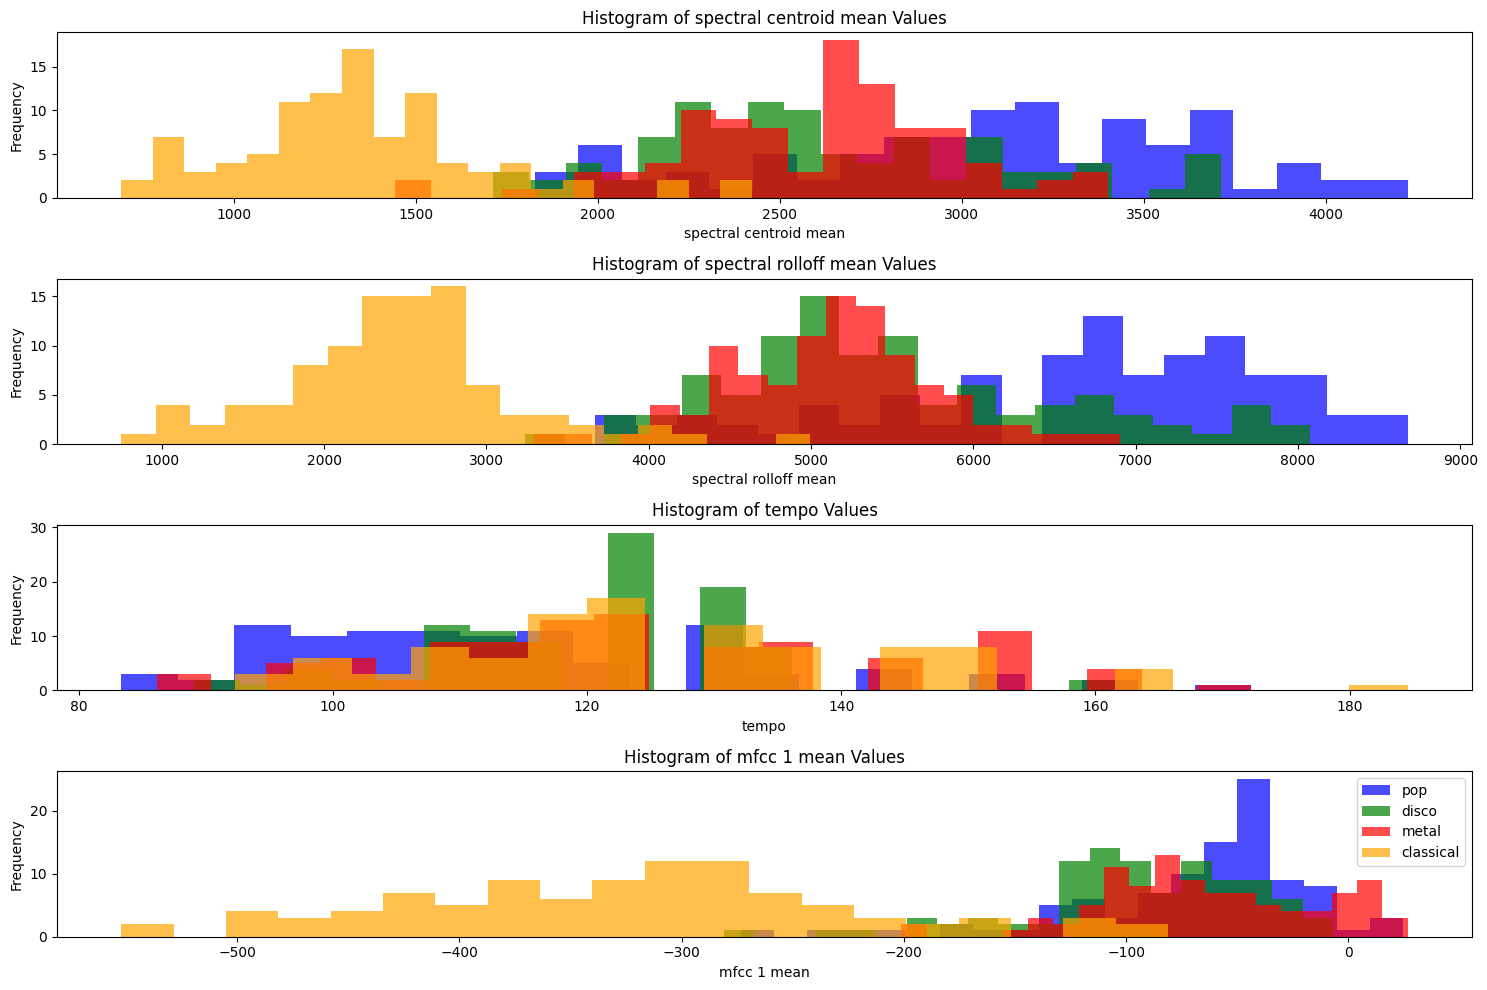

In [104]:
# Data fra den markerte koden
classes = ['pop', 'disco', 'metal', 'classical']
data = [pop_data_sorted, disco_data_sorted, metal_data_sorted, classical_data_sorted]
colors = ['blue', 'green', 'red', 'orange']



# histogram
plt.figure(figsize=(15, 10))
plt.subplot(4, 1, 1)
for i,cls in enumerate(classes):
    plt.hist(data[i][0], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of spectral centroid mean Values')
plt.xlabel('spectral centroid mean')
plt.ylabel('Frequency')

plt.subplot(4, 1, 2)
for i,cls in enumerate(classes):
    plt.hist(data[i][1], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of spectral rolloff mean Values')
plt.xlabel('spectral rolloff mean')
plt.ylabel('Frequency')

plt.subplot(4, 1, 3)
for i,cls in enumerate(classes):
    plt.hist(data[i][2], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of tempo Values')
plt.xlabel('tempo')
plt.ylabel('Frequency')

plt.subplot(4, 1, 4)
for i,cls in enumerate(classes):
    plt.hist(data[i][3], bins=20, alpha=0.7, label=cls, color=colors[i])
plt.title('Histogram of mfcc 1 mean Values')
plt.xlabel('mfcc 1 mean')
plt.ylabel('Frequency')
plt.tight_layout()
plt.legend()
plt.show()


